In [136]:
import pandas as pd 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.decomposition import PCA



In [137]:
df = pd.read_csv("../data/processed/clean_data.csv")

In [138]:
numeric_colones= [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]
categoral_colones =[
    "SeniorCitizen",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]
pre = ColumnTransformer(
    transformers =[
        ('num',StandardScaler(),numeric_colones),
        ('cat',OneHotEncoder(handle_unknown="ignore"),categoral_colones)
    ]
)
X_prepared = pre.fit_transform(df)

Certaines variables ont été retirées afin de limiter la redondance et de conserver les caractéristiques les plus pertinentes pour la segmentation des clients. La variable ``` gender```  a été supprimée car elle apporte peu d'information sur le comportement d'utilisation des services. ```PhoneService``` a également été retirée car elle est fortement liée à MultipleLines, ce qui peut introduire une information redondante. 

2 => 0.28887300515575254 => 1.1740537551780015 => 2525.197231467049
3 => 0.28861311699948333 => 1.4472118068096902 => 2779.7594895322813
4 => 0.23920062690753074 => 1.7548200431398135 => 2261.743906767651
5 => 0.2211926427053424 => 1.9051895522666655 => 1927.80794945955
6 => 0.1845651350649188 => 1.863352564658267 => 1692.022637116456
7 => 0.16665676813571653 => 1.8729859665695503 => 1525.7619839303193
8 => 0.15285042798308704 => 2.0371181988059943 => 1386.8519847101757
9 => 0.15076141207704444 => 2.0843931351385034 => 1274.2616166663556
10 => 0.15248032917862567 => 2.14331796363093 => 1173.485544114283


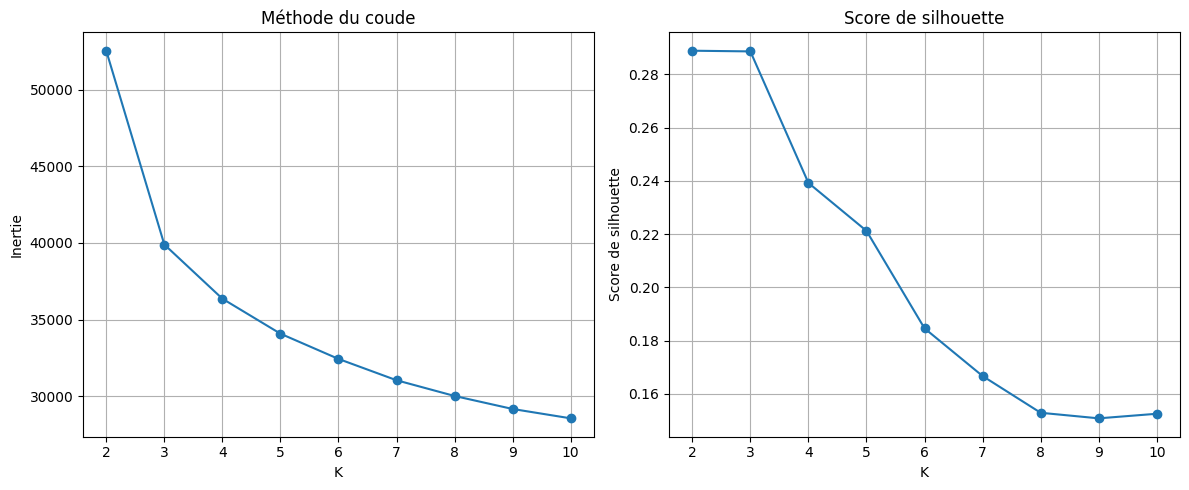

In [139]:
k_values = range(2, 11)
inertie = []
silhouette_scores =[]

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_prepared)

    score = silhouette_score(
        X_prepared,labels
    )
    db_score = davies_bouldin_score(
        X_prepared,
        labels
    )

    ch_score = calinski_harabasz_score(
        X_prepared,
        labels
    )
    silhouette_scores.append(score)
    inertie.append(model.inertia_)

    print(f"{k} => {score} => {db_score} => {ch_score}")



plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

plt.plot(list(k_values), inertie, marker="o")

plt.xlabel("K")
plt.ylabel("Inertie")
plt.title("Méthode du coude")

plt.xticks(list(k_values))
plt.grid(True)


plt.subplot(1, 2, 2)

plt.plot(list(k_values), silhouette_scores, marker="o")

plt.xlabel("K")
plt.ylabel("Score de silhouette")
plt.title("Score de silhouette")

plt.xticks(list(k_values))
plt.grid(True)

plt.tight_layout()
plt.show()



In [140]:
dbscan = DBSCAN(
    eps=2.5,
    min_samples=5
)

lable = dbscan.fit_predict(X_prepared)

silhouette_score_DBSCAN = silhouette_score(
    X_prepared,lable
)
db_score_dbSCAN = davies_bouldin_score(
    X_prepared,
    lable
)
ch_score_db_scan = calinski_harabasz_score(
    X_prepared,
    lable
)
print("silhoutee : ",silhouette_score_DBSCAN)
print("Davies-Bouldin : ",db_score_dbSCAN)
print("ch_score : ",ch_score_db_scan)


silhoutee :  0.28887300515575254
Davies-Bouldin :  1.1740537551780015
ch_score :  2525.197231467049


In [141]:
for k in range(2, 11):

    agglomerative = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = agglomerative.fit_predict(X_prepared)

    score = silhouette_score(
        X_prepared,
        labels
    )
    db_score_agg = davies_bouldin_score(
        X_prepared,
        labels
    )
    ch_score_agg = calinski_harabasz_score(
        X_prepared,
        labels
    )

    print(f"K={k} → {score} -> {db_score_agg} -> {ch_score_agg}")

K=2 → 0.28887300515575254 -> 1.1740537551780015 -> 2525.197231467049
K=3 → 0.26338207291084925 -> 1.5500475354107237 -> 2528.1866369035483
K=4 → 0.2097145036005405 -> 1.7224741611709211 -> 1986.2031723499683
K=5 → 0.19924793658051201 -> 2.036278937700687 -> 1743.0928835215655
K=6 → 0.1973480240472306 -> 2.0489553047687634 -> 1506.9276129996006
K=7 → 0.14716580951353372 -> 2.0723667738126657 -> 1348.306270927505
K=8 → 0.14184204500341974 -> 2.2430959752856148 -> 1217.6021567921166
K=9 → 0.1333568407848854 -> 2.3315844386992524 -> 1117.3240812884699
K=10 → 0.1051521380505018 -> 2.4169491939562873 -> 1034.7947000191432


In [142]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_prepared)

df["Cluster"] = labels

df.groupby("Cluster")[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean().round(2)

df["Cluster"].value_counts()

# pd.crosstab(
#     df["Cluster"],
#     df["Churn"],
#     normalize="index"
# ).mul(100).round(2)

Cluster
0    3206
1    2311
2    1526
Name: count, dtype: int64

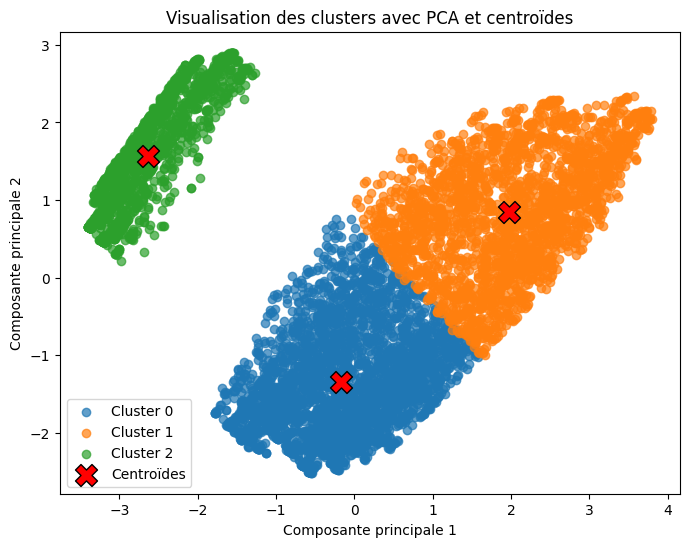

In [143]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_prepared)

df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

df_pca["Cluster"] = labels

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))

# Afficher les points des clusters
for cluster in sorted(df_pca["Cluster"].unique()):

    data = df_pca[df_pca["Cluster"] == cluster]

    plt.scatter(
        data["PC1"],
        data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

# Afficher les centroïdes
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=250,
    color="red",
    edgecolors="black",
    label="Centroïdes"
)

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Visualisation des clusters avec PCA et centroïdes")
plt.legend()
plt.show()



In [144]:
df.to_csv("../data/processed/customer_clusters.csv",index=False)